In [1]:
import importlib
import numpy as np
import polars as pl
import torch

from datasets import DATA_FOLDER, prepare_interaction_data
from train_sae import SAE_EXTRA_PARAMS
from util import CHECKPOINT_FOLDER, get_checkpoint_filepath, load_checkpoint, load_config_from_checkpoint
epsilon = 1e-9
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

DATASET = "ml-25m"
SAE_CHECKPOINT_PATH = f"{CHECKPOINT_FOLDER}/{DATASET}/TopKSAE-8192-273f0cbb.ckpt"

sae_cfg = load_config_from_checkpoint(SAE_CHECKPOINT_PATH)
elsa_checkpoint_path = f"{CHECKPOINT_FOLDER}/{DATASET}/{sae_cfg['pretrained_model_checkpoint']}"
elsa_cfg = load_config_from_checkpoint(elsa_checkpoint_path)

interactions_df, train_csr, val_csr, test_csr, train_users, val_users, test_users, items = prepare_interaction_data(elsa_cfg)
train_users_to_idxs = {uid: uidx for uidx, uid in enumerate(train_users)}
val_users_to_idxs = {uid: uidx for uidx, uid in enumerate(val_users)}
test_users_to_idxs = {uid: uidx for uidx, uid in enumerate(test_users)}
items_to_idxs = {iid: iidx for iidx, iid in enumerate(items)}
idxs_to_items = {iidx: iid for iidx, iid in enumerate(items)}



items_df = (
    pl.scan_csv(f"{DATA_FOLDER}/{DATASET}/movies.csv").rename({"movieId": "item_id"}).cast({"item_id": pl.String}).cast({"item_id": pl.Categorical}).collect()
)

elsa_model_class = getattr(importlib.import_module(elsa_cfg["model_module"]), elsa_cfg["model_class"])
elsa = elsa_model_class(train_csr.shape[1], elsa_cfg["embedding_dim"], elsa_cfg["seed"]).to(device)
_, _ = load_checkpoint(elsa, None, get_checkpoint_filepath(elsa_cfg), device, None)

sae_model_class = getattr(importlib.import_module(sae_cfg["model_module"]), sae_cfg["model_class"])
sae_extra_params = {k: sae_cfg[k] for k in sae_cfg.keys() if k in SAE_EXTRA_PARAMS}
sae = sae_model_class(elsa_cfg["embedding_dim"], sae_cfg["embedding_dim"], sae_cfg["seed"], l1_coef=sae_cfg["l1_coef"], k=sae_cfg["k"]).to(device)
_, _ = load_checkpoint(sae, None, get_checkpoint_filepath(sae_cfg), device, None)

Dataset info: users=162342, items=40858, interactions=12452811
Train split info: users=129874, items=40858, interactions=9961684
Val split info: users=16234, items=40858, interactions=1246445
Test split info: users=16234, items=40858, interactions=1244682
Loaded checkpoint from checkpoints/ml-25m/ELSA-1024-c6d19aef.ckpt (after 50 epochs)
Loaded checkpoint from checkpoints/ml-25m/TopKSAE-8192-273f0cbb.ckpt (after 210 epochs)


In [2]:
maxCount = 50000

from scipy.sparse import coo_matrix, vstack

sparse_embeds = []

for k, i in enumerate(items):
    if k % 100 == 0:
        print(k, len(items))
    if k > maxCount:
        break
    iVector = np.zeros(len(items))
    iVector[items_to_idxs[i]] = 1
    interaction_tensor = torch.tensor(iVector.reshape(1, -1)).to(device).float()
    elsa_embedding = elsa.encode(interaction_tensor) # Tensor, shape = (1 x elsa_cfg["embedding_dim"])
    sae_embedding, _, input_mean, input_std = sae.encode(elsa_embedding) 
    sparse_embeds.append(coo_matrix(sae_embedding.detach().numpy()))
stacked = vstack(sparse_embeds)

0 40858
100 40858
200 40858
300 40858
400 40858
500 40858
600 40858
700 40858
800 40858
900 40858
1000 40858
1100 40858
1200 40858
1300 40858
1400 40858
1500 40858
1600 40858
1700 40858
1800 40858
1900 40858
2000 40858
2100 40858
2200 40858
2300 40858
2400 40858
2500 40858
2600 40858
2700 40858
2800 40858
2900 40858
3000 40858
3100 40858
3200 40858
3300 40858
3400 40858
3500 40858
3600 40858
3700 40858
3800 40858
3900 40858
4000 40858
4100 40858
4200 40858
4300 40858
4400 40858
4500 40858
4600 40858
4700 40858
4800 40858
4900 40858
5000 40858
5100 40858
5200 40858
5300 40858
5400 40858
5500 40858
5600 40858
5700 40858
5800 40858
5900 40858
6000 40858
6100 40858
6200 40858
6300 40858
6400 40858
6500 40858
6600 40858
6700 40858
6800 40858
6900 40858
7000 40858
7100 40858
7200 40858
7300 40858
7400 40858
7500 40858
7600 40858
7700 40858
7800 40858
7900 40858
8000 40858
8100 40858
8200 40858
8300 40858
8400 40858
8500 40858
8600 40858
8700 40858
8800 40858
8900 40858
9000 40858
9100 40858


In [3]:
stacked

<40858x8192 sparse matrix of type '<class 'numpy.float32'>'
	with 642190 stored elements in COOrdinate format>

In [4]:
import pandas as pd

activations_csr = stacked.tocsr()

column_sum = activations_csr.sum(axis=0)
column_sum = np.squeeze(np.array(column_sum).T)
column_sum

array([28.284052 ,  0.       ,  2.9969277, ...,  0.       , 25.697237 ,
       36.80129  ], dtype=float32)

In [5]:
pd.Series(column_sum).describe()

count     8192.000000
mean       190.463226
std        912.038086
min          0.000000
25%          0.289207
50%          2.565182
75%         18.352048
max      30072.300781
dtype: float64

In [6]:
np.count_nonzero(column_sum)

6733

# From TagGenome to Neurons

In [7]:
tagNames = pd.read_csv(DATA_FOLDER+"/ml-25m/genome-tags.csv")
tagScores = pd.read_csv(DATA_FOLDER+"/ml-25m/genome-scores.csv")

In [8]:
tagScoresReduced = tagScores[tagScores['relevance'] >= tagScores.relevance.quantile(0.90)]
tagScoresReduced["idx"] = [items_to_idxs[str(i)] for i in tagScoresReduced.movieId]
tagScoresReduced = tagScoresReduced[tagScoresReduced.idx < maxCount]
tagScoresReduced

C:\Users\lpesk\AppData\Local\Temp\ipykernel_20820\165618775.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tagScoresReduced["idx"] = [items_to_idxs[str(i)] for i in tagScoresReduced.movieId]


,movieId,tagId,relevance,idx
10,1,11,0.58025,149
18,1,19,0.66250,149
19,1,20,0.30075,149
20,1,21,0.31675,149
28,1,29,0.89375,149
...,...,...,...,...
15584410,206499,1091,0.38400,15304
15584420,206499,1101,0.43075,15304
15584422,206499,1103,0.35375,15304
15584423,206499,1104,0.36950,15304


In [66]:
from scipy.stats import entropy
resEntropy = []
colSums = {}
for t in tagScoresReduced.tagId.unique():
    tName = tagNames.loc[tagNames.tagId == t, "tag"].iloc[0]
    tData = tagScoresReduced[tagScoresReduced.tagId == t]
    noMovies = tData.movieId.unique().shape[0]
    support = tData.relevance.sum()
    activations_t = activations_csr[tData.idx]
    activations_t = activations_t.multiply(tData.relevance.values[:, np.newaxis])
    column_sum_t = activations_t.sum(axis=0)
    column_sum_t = np.squeeze(np.array(column_sum_t).T)
    colSums[t] = column_sum_t
    entropy_t = entropy(column_sum_t)

    column_sum_t = column_sum_t+epsilon
    KLdiv_t = entropy(column_sum, column_sum_t)
    
    resEntropy.append({"tagId":t, "tagName": tName, "entropy":entropy_t, "KL_div":KLdiv_t, "tagSupport":support, "noOfMovies":noMovies})
    


In [71]:
entropy_fullData = entropy(column_sum)

entropyDF = pd.DataFrame(resEntropy).sort_values("entropy")
entropyDF["normalized_entropy_diff"] = (entropy_fullData - entropyDF.entropy) / entropy_fullData

entropyDF.head(10)

,tagId,tagName,entropy,KL_div,tagSupport,noOfMovies,normalized_entropy_diff
1119,1030,tolkien,3.401261,16.910747,8.64175,13,0.485851
1054,957,spock,3.501335,16.422593,11.24025,15,0.470723
1066,15,aardman,3.526728,14.756885,11.46125,14,0.466884
1126,492,harry potter,3.567008,12.449886,18.15125,31,0.460795
1122,657,miyazaki,3.632986,12.536848,22.99725,35,0.450822
1110,633,marx brothers,3.648829,13.293481,13.87100,18,0.448427
1120,859,robert ludlum,3.723335,17.295593,7.35375,11,0.437164
1125,347,emma watson,3.739190,12.626700,20.21775,24,0.434768
1124,976,studio ghibli,3.754023,11.779017,27.27025,38,0.432525
1123,698,neil gaiman,3.874807,17.049618,5.05825,9,0.414267


In [70]:
entropyDF.loc[entropyDF.noOfMovies>100].head(10)

,tagId,tagName,entropy,KL_div,tagSupport,noOfMovies,normalized_entropy_diff
928,632,marvel,5.026185,7.495211,88.84850,121,0.240220
1038,541,india,5.106156,6.179064,96.01850,133,0.228131
403,151,bond,5.136077,6.173244,66.46100,106,0.223608
1067,65,anime,5.186258,4.757317,177.48225,249,0.216023
1013,16,aardman studios,5.188852,6.606214,94.11275,202,0.215630
1099,1128,zombies,5.237383,6.343209,121.85350,160,0.208294
930,1105,werewolf,5.245193,5.555838,103.07550,193,0.207114
992,486,halloween,5.252291,5.307968,102.88250,179,0.206041
936,31,afi 100,5.253099,8.534064,65.73450,120,0.205919
1033,873,samurai,5.267229,6.023517,100.30025,146,0.203783


In [74]:
entropyDF.corr(numeric_only=True)["entropy"]

tagId                      0.003801
entropy                    1.000000
KL_div                    -0.955319
tagSupport                 0.519861
noOfMovies                 0.531322
normalized_entropy_diff   -1.000000
Name: entropy, dtype: float64

In [76]:
entropyDF.corr(method="spearman",numeric_only=True)["entropy"]

tagId                      0.011878
entropy                    1.000000
KL_div                    -0.949433
tagSupport                 0.913353
noOfMovies                 0.923748
normalized_entropy_diff   -1.000000
Name: entropy, dtype: float64

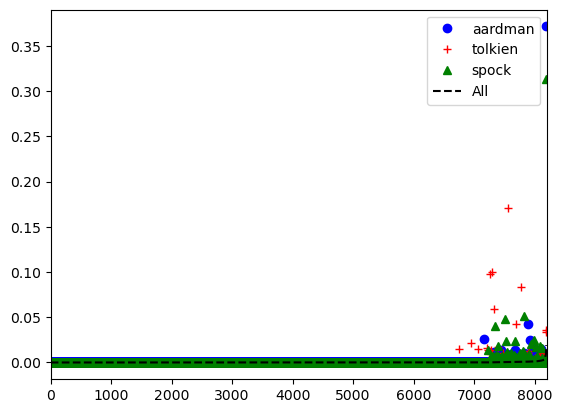

In [78]:
from matplotlib import pyplot as plt
plt.plot(colSums[15][np.argsort(column_sum)]/colSums[15].sum(),'bo', label="aardman")
plt.plot(colSums[1030][np.argsort(column_sum)]/colSums[1030].sum(),'r+', label="tolkien")
plt.plot(colSums[957][np.argsort(column_sum)]/colSums[957].sum(),'g^', label="spock")

plt.plot(column_sum[np.argsort(column_sum)]/column_sum.sum(),'--', label="All", color="black")

plt.xlim(000,8200)
plt.legend()

In [79]:
entropyDF.tail(10)

,tagId,tagName,entropy,KL_div,tagSupport,noOfMovies,normalized_entropy_diff
46,302,dialogue,6.687664,0.240383,5671.08150,11873,-0.010937
104,553,intense,6.689135,0.422513,2937.44175,5783,-0.011159
87,468,great ending,6.689889,0.227097,6315.51675,12826,-0.011273
86,465,great acting,6.694454,0.476977,3284.12675,6224,-0.011963
179,1072,very good,6.697887,0.628260,1654.28675,3955,-0.012482
30,220,clever,6.698723,0.424714,2931.83550,6309,-0.012608
160,971,story,6.699182,0.302037,4487.38275,9061,-0.012678
77,445,good,6.706234,0.331775,4650.23250,9220,-0.013744
85,464,great,6.711187,0.308450,4665.68700,9861,-0.014492
88,469,great movie,6.712646,0.504538,2764.57550,5477,-0.014713


In [80]:
entropyDF.describe()

,tagId,entropy,KL_div,tagSupport,noOfMovies,normalized_entropy_diff
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,564.500000,6.065595,2.904278,692.336804,1382.189716,0.083098
std,325.769857,0.542573,3.074103,964.532552,1924.327830,0.082018
min,1.000000,3.401261,0.187746,1.835250,5.000000,-0.014713
25%,282.750000,5.863795,0.832035,121.911438,220.750000,0.025679
50%,564.500000,6.197496,1.769663,324.067125,614.500000,0.063159
75%,846.250000,6.445444,3.735650,845.810125,1676.250000,0.113603
max,1128.000000,6.712646,17.295593,10008.644000,13816.000000,0.485851


# From Tags to Neurons

In [82]:
rawTags = pd.read_csv(DATA_FOLDER+"/ml-25m/tags.csv")
rawTags

,userId,movieId,tag,timestamp
0,3,260,classic,1439472355
1,3,260,sci-fi,1439472256
2,4,1732,dark comedy,1573943598
3,4,1732,great dialogue,1573943604
4,4,7569,so bad it's good,1573943455
...,...,...,...,...
1093355,162521,66934,Neil Patrick Harris,1427311611
1093356,162521,103341,cornetto trilogy,1427311259
1093357,162534,189169,comedy,1527518175
1093358,162534,189169,disabled,1527518181


In [83]:
validTags = rawTags.tag.value_counts()
validTagThreshold = validTags.quantile(0.99)
validTags = validTags.loc[validTags >= validTagThreshold]
validTags

tag
sci-fi                8330
atmospheric           6516
action                5907
comedy                5702
surreal               5326
                      ... 
Hugh Grant             244
seen at the cinema     243
Australia              243
Terry Gilliam          243
Jack Black             243
Name: count, Length: 732, dtype: int64

In [84]:
rawTags = rawTags.loc[rawTags.tag.isin(validTags.index),["userId","movieId","tag"]]
tagCounts = rawTags.groupby(["movieId","tag"]).count().reset_index()
tagCounts["idx"] = [items_to_idxs.get(str(i),-1) for i in tagCounts.movieId]
tagCounts = tagCounts[tagCounts.idx < maxCount]
tagCounts = tagCounts[tagCounts.idx!=-1]
tagCounts

,movieId,tag,userId,idx
0,1,Animation,1,149
1,1,BD-Video,1,149
2,1,CLV,1,149
3,1,DVD-Video,1,149
4,1,Disney,42,149
...,...,...,...,...
162906,209037,computer animation,1,40130
162907,209037,humorous,1,40130
162908,209037,nature,1,40130
162909,209063,racism,1,36529


In [85]:
from scipy.stats import entropy
resEntropyRT = []
colSumsRT = {}
for t in tagCounts.tag.unique():
    tName = t
    tData = tagCounts[tagCounts.tag == t]
    noMovies = tData.movieId.unique().shape[0]
    noUsers = tData.userId.unique().shape[0]
    activations_t = activations_csr[tData.idx]
    activations_t = activations_t.multiply(tData.userId.values[:, np.newaxis])
    column_sum_t = activations_t.sum(axis=0)
    column_sum_t = np.squeeze(np.array(column_sum_t).T)
    colSumsRT[t] = column_sum_t
    entropy_t = entropy(column_sum_t)
    
    column_sum_t = column_sum_t+epsilon
    KLdiv_t = entropy(column_sum, column_sum_t)
    
    

    resEntropyRT.append({"tagId":t, "tagName": tName, "entropy":entropy_t, "KL_div":KLdiv_t, "tagUsed":tData.shape[0], "noOfMovies":noMovies, "noOfUsers":noUsers})
    

In [87]:
entropyRT_DF = pd.DataFrame(resEntropyRT).sort_values("entropy")
entropyRT_DF["normalized_entropy_diff"] = (entropy_fullData - entropyRT_DF.entropy) / entropy_fullData

entropyRT_DF.head(10)

,tagId,tagName,entropy,KL_div,tagUsed,noOfMovies,noOfUsers,normalized_entropy_diff
458,Hayao Miyazaki,Hayao Miyazaki,2.581209,19.946260,15,15,14,0.609813
600,space adventure,space adventure,2.711612,22.125182,8,8,5,0.590101
715,Studio Ghibli,Studio Ghibli,2.776263,17.513105,22,22,21,0.580328
696,Monty Python,Monty Python,2.808708,20.497066,9,9,7,0.575423
551,Science Fiction,Science Fiction,3.084119,15.668719,26,26,10,0.533791
451,Wes Anderson,Wes Anderson,3.190993,22.784141,9,9,9,0.517636
679,David Lynch,David Lynch,3.217247,18.619279,16,16,11,0.513667
587,George Lucas,George Lucas,3.260441,21.698860,11,11,11,0.507138
588,Sci-fi,Sci-fi,3.521772,16.966480,18,18,9,0.467634
590,Star Wars,Star Wars,3.534511,17.542702,20,20,14,0.465708


In [88]:
entropyRT_DF.loc[entropyRT_DF.noOfMovies>100].head(10)

,tagId,tagName,entropy,KL_div,tagUsed,noOfMovies,noOfUsers,normalized_entropy_diff
624,spaghetti western,spaghetti western,3.625727,11.467992,102,102,11,0.451919
591,anime,anime,3.988757,6.874912,267,267,32,0.397042
682,bollywood,bollywood,4.278403,9.937295,157,157,11,0.353258
701,possession,possession,4.399434,8.919204,114,114,10,0.334962
685,zombies,zombies,4.414367,8.344337,165,165,30,0.332705
648,slasher,slasher,4.458420,6.602280,213,213,16,0.326046
684,zombie,zombie,4.584949,7.299711,225,225,13,0.306919
323,kung fu,kung fu,4.649349,8.364514,125,125,15,0.297184
0,Animation,Animation,4.657873,8.928527,105,105,16,0.295896
657,stand-up comedy,stand-up comedy,4.679124,7.412385,337,337,13,0.292683


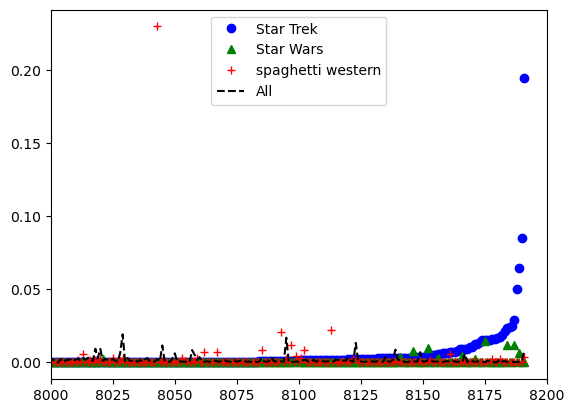

In [89]:
from matplotlib import pyplot as plt
plt.plot(colSumsRT["Star Trek"][np.argsort(colSumsRT["Star Trek"])]/colSumsRT["Star Trek"].sum(),'bo', label="Star Trek")
plt.plot(colSumsRT["Star Wars"][np.argsort(colSumsRT["Star Trek"])]/colSumsRT["Quentin Tarantino"].sum(),'g^', label="Star Wars")
plt.plot(colSumsRT["spaghetti western"][np.argsort(colSumsRT["Star Trek"])]/colSumsRT["spaghetti western"].sum(),'r+', label="spaghetti western")


plt.plot(column_sum[np.argsort(colSumsRT["Star Trek"])]/column_sum.sum(),'--', label="All", color="black")

plt.xlim(8000,8200)
plt.legend()

In [90]:
entropyRT_DF.tail(10)

,tagId,tagName,entropy,KL_div,tagUsed,noOfMovies,noOfUsers,normalized_entropy_diff
414,loss of loved one,loss of loved one,6.376946,1.808508,331,331,3,0.036033
53,parent child relationship,parent child relationship,6.401558,1.410270,531,531,5,0.032313
247,reviewed,reviewed,6.407224,1.834477,387,387,3,0.031456
2,CLV,CLV,6.408567,1.228921,1336,1336,3,0.031253
85,murder,murder,6.413271,0.789074,1706,1706,21,0.030542
66,Tumey's DVDs,Tumey's DVDs,6.420885,2.019395,649,649,2,0.029391
1,BD-Video,BD-Video,6.444073,1.595968,685,685,2,0.025886
47,based on novel or book,based on novel or book,6.467135,0.781975,912,912,5,0.022400
192,nudity (topless),nudity (topless),6.470758,0.676999,1209,1209,8,0.021852
3,DVD-Video,DVD-Video,6.518457,1.047324,915,915,3,0.014642


In [91]:
entropyRT_DF.describe()

,entropy,KL_div,tagUsed,noOfMovies,noOfUsers,normalized_entropy_diff
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,5.209917,7.548924,200.586066,200.586066,18.135246,0.212446
std,0.647165,4.445911,251.389582,251.389582,10.473183,0.097828
min,2.581209,0.661559,8.000000,8.000000,1.000000,0.014642
25%,4.804018,4.255982,62.750000,62.750000,12.000000,0.145112
50%,5.266929,6.392261,129.500000,129.500000,16.000000,0.203828
75%,5.655352,10.168723,237.250000,237.250000,21.000000,0.273804
max,6.518457,22.860438,3126.000000,3126.000000,77.000000,0.609813


# From Neurons to Tags

In [92]:
movies = pd.read_csv(DATA_FOLDER+"/ml-25m/movies.csv")
items_to_title = {r.movieId:r.title for i,r in movies.iterrows()}
movies

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
62418,209157,We (2018),Drama
62419,209159,Window of the Soul (2001),Documentary
62420,209163,Bad Poems (2018),Comedy|Drama
62421,209169,A Girl Thing (2001),(no genres listed)


In [93]:
tag_to_idx = {t:idx for idx,t in enumerate(tagCounts.tag.unique())}
idx_to_tag = {idx:t for idx,t in enumerate(tagCounts.tag.unique())}
tag_to_idx

{'Animation': 0,
 'BD-Video': 1,
 'CLV': 2,
 'DVD-Video': 3,
 'Disney': 4,
 'National Film Registry': 5,
 'Pixar': 6,
 'Tom Hanks': 7,
 'USA': 8,
 'action': 9,
 'adventure': 10,
 'animated': 11,
 'animation': 12,
 'bullying': 13,
 'cgi': 14,
 'childish': 15,
 'children': 16,
 'classic': 17,
 'clever': 18,
 'comedy': 19,
 'computer animation': 20,
 'cute': 21,
 'family': 22,
 'fantasy': 23,
 'friends': 24,
 'friendship': 25,
 'fun': 26,
 'funny': 27,
 'humorous': 28,
 'imdb top 250': 29,
 'jealousy': 30,
 'martial arts': 31,
 'nostalgic': 32,
 'pixar': 33,
 'sci-fi': 34,
 'story': 35,
 'time travel': 36,
 'witty': 37,
 'Fantasy': 38,
 'Robin Williams': 39,
 'adapted from:book': 40,
 'animals': 41,
 'based on a book': 42,
 'jungle': 43,
 'scary': 44,
 'duringcreditsstinger': 45,
 'sequel': 46,
 'based on novel or book': 47,
 'characters': 48,
 'chick flick': 49,
 'divorce': 50,
 'revenge': 51,
 'Comedy': 52,
 'parent child relationship': 53,
 'pregnancy': 54,
 'wedding': 55,
 'Action': 5

In [154]:
tagIDF = np.log(tagCounts["movieId"].nunique()/tagCounts.groupby("tag")["movieId"].nunique())
tagIDF.sort_values()

tag
BD-R                 2.193628
woman director       2.373649
murder               2.799231
independent film     2.927251
based on a book      3.032537
                       ...   
Christopher Nolan    7.843242
David Fincher        7.938553
Wes Anderson         8.043913
Monty Python         8.043913
space adventure      8.161696
Name: movieId, Length: 732, dtype: float64

In [155]:
neuron_tags_activation = []
neuron_top_tags = []
activated_movies = []
activated_movies_sum = []
neuron_tags_sum = []
for neuron in range(activations_csr.shape[1]):
#for neuron in range(500):
    neuron_activations = activations_csr[:,neuron].tocoo()
    idxs = neuron_activations.row
    movieIds = [int(idxs_to_items[i]) for i in idxs]
    movieTitles = [items_to_title.get(int(i), -1) for i in movieIds]    
    vals = neuron_activations.data
    d = pd.DataFrame({"idx":idxs, "movieId":movieIds, "title":movieTitles, "activation":vals}) 
    support_movies = d.movieId.unique().shape[0]
    neuron_tags = tagCounts.loc[tagCounts.movieId.isin(d.movieId)]
    tag_norm = neuron_tags.userId.sum()
    
    tagActivation = d.set_index("movieId").join(neuron_tags.set_index("movieId"), rsuffix='_tag').dropna()
    tagActivation["tgAct"] = tagActivation["activation"] * tagActivation["userId"]
    groupTagAct = tagActivation.groupby("tag")["tgAct"].sum()
    groupMovieAct = tagActivation.groupby("title")["tgAct"].sum()
    
    ind = [tag_to_idx[t] for t in groupTagAct.index]
    val = groupTagAct.values
    vector = np.zeros(len(tag_to_idx))
    np.put(vector, ind, val)

    #topMovies = d.sort_values("activation").head(5).title
    topMovies = [i for i in groupMovieAct.sort_values(ascending=False).head(5).index]
    neuron_tags_sum.append(tag_norm)
    activated_movies.append(topMovies)
    activated_movies_sum.append(support_movies)
    neuron_tags_activation.append(vector)

    topActivatedTags = tagActivation.groupby("tag")["tgAct"].sum() * tagIDF    
    
    neuron_top_tags.append(topActivatedTags.sort_values(ascending=False).head(25))
    if neuron % 100 == 0:    
        print(neuron)

    

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100


In [156]:
sumTagActivation = np.array(neuron_tags_activation).sum(axis=0)

tagSum = tagCounts.groupby("tag")["userId"].sum()
tagIDX = [tag_to_idx[t] for t,val in tagSum.items()]
tagVAL = tagSum.values
sumTagAssociation = np.zeros(tagCounts.tag.unique().shape[0])
np.put(sumTagAssociation, tagIDX, tagVAL)

In [157]:
entropy_sumTagActivation = entropy(sumTagActivation)
entropy_sumTagAssociation = entropy(sumTagAssociation)

entropy_sumTagActivation, entropy_sumTagAssociation

(6.093293901039546, 6.188601562468157)

In [158]:
entropy(sumTagActivation,sumTagAssociation)
#i.e., the sum of activations for each tag is proportional to the sum of its association with movies (=> no tag is being under-activated)
# we can keep using only tag activations in future code

0.033598390476100914

In [159]:
resEntropyRev = []

for i,r in enumerate(neuron_tags_activation):
    movies = activated_movies[i]
    support = activated_movies_sum[i]
    tagsSum = neuron_tags_sum[i]
    tags = neuron_top_tags[i]
    tags = tags.index[:5]
    
    entropy_t = entropy(r)

    
    r = r+epsilon
    KLdiv_t_activ = entropy(sumTagActivation, r)

    
    resEntropyRev.append({"id":i, 
                          "entropy":entropy_t, 
                          "KL_div":KLdiv_t_activ, 
                          "noOfMovies": support,
                          "tagUsed": tagsSum,
                          "top_tags_TFIDF": tags.tolist(),
                          "top_movies": movies
                         })
    

In [160]:
entropyRev_DF = pd.DataFrame(resEntropyRev).sort_values("entropy")
entropyRev_DF["normalized_entropy_diff"] = (entropy_sumTagActivation - entropyRev_DF.entropy) / entropy_sumTagActivation


#remove dead neurons ( >0 ) / remove neurons with low support (>minMovies)
minMovies = 0
entropyRev_DF = entropyRev_DF[entropyRev_DF.noOfMovies > minMovies]

In [161]:
pd.options.display.max_colwidth = 50
entropyRev_DF.sort_values("KL_div", ascending=False).head(25)

,id,entropy,KL_div,noOfMovies,tagUsed,top_tags_TFIDF,top_movies,normalized_entropy_diff
2910,2910,2.983792,20.627508,5,935,"[zombies, post-apocalyptic, Bill Murray, Emma ...","[Zombieland (2009), Hobson's Choice (1954), Ri...",0.510315
3290,3290,2.336677,20.424618,1,263,"[James Bond, espionage, action, spy, gambling]",[Casino Royale (2006)],0.616517
1356,1356,3.084743,20.051603,2,632,"[self discovery, road trip, based on a true st...","[Into the Wild (2007), Trippin' (1999)]",0.493748
3662,3662,3.566558,19.592036,2,1757,"[Simon Pegg, zombies, british comedy, black co...","[Shaun of the Dead (2004), Snatch (2000)]",0.414675
126,126,3.215351,19.548097,3,1154,"[time travel, sci-fi, alternate reality, adven...","[Back to the Future (1985), Back to the Future...",0.472313
6180,6180,3.439308,19.497576,2,1961,"[twist ending, powerful ending, serial killer,...","[Seven (a.k.a. Se7en) (1995), Interview with t...",0.435558
6507,6507,3.661330,19.311170,5,1389,"[Monty Python, Harrison Ford, british comedy, ...","[Monty Python and the Holy Grail (1975), India...",0.399121
6243,6243,3.371400,19.169774,3,980,"[dark comedy, black comedy, british comedy, st...","[In Bruges (2008), Seven Psychopaths (2012), G...",0.446703
6062,6062,2.840217,19.008539,2,271,"[time travel, sci-fi, sequel, comedy, 1980s]","[Back to the Future Part II (1989), Cars 3 (20...",0.533878
1031,1031,2.379063,18.830606,1,87,"[musical, movie business, classic, comedy, dance]",[Singin' in the Rain (1952)],0.609560


In [164]:
entropyRev_DF.loc[entropyRev_DF.noOfMovies > 50].sort_values("KL_div", ascending=False).head(25)

,id,entropy,KL_div,noOfMovies,tagUsed,top_tags_TFIDF,top_movies,normalized_entropy_diff
4572,4572,3.073077,16.870617,51,93,"[plot twist, Science Fiction, alien invasion, ...","[Extinction (2018), Incendiary (2008), Inferno...",0.495663
6894,6894,3.348158,16.392718,53,65,"[stand-up comedy, woman director, BD-R, russia...","[Morphia (Morfiy) (2008), David Cross: Making ...",0.450518
977,977,3.612395,16.369778,68,66,"[1950s, loneliness, might like, obsession, com...","[Harriet Craig (1950), Gormenghast (2000), The...",0.407152
7883,7883,3.912123,16.355142,62,85,"[school, humor, pirates, short, high school]","[Hurricane Bianca (2016), The Tramp (1915), It...",0.357962
7949,7949,4.371731,16.350168,67,431,"[neo-noir, lesbian, atmospheric, stylish, gay]","[Bound (1996), Eyes Without a Face (Yeux sans ...",0.282534
4668,4668,3.291517,16.336680,58,61,"[witch, mad scientist, woman director, indepen...",[Season of the Witch (Hungry Wives) (Jack's Wi...,0.459813
2031,2031,3.676405,16.304168,64,101,"[stand-up comedy, survival, murder, parent chi...","[Invisible Man Returns, The (1940), Walking Ou...",0.396647
4526,4526,3.666369,16.269111,65,80,"[woman director, psychopath, kidnapping, tortu...","[No One Lives (2012), Boy Missing (2016), Tuli...",0.398294
6189,6189,3.762820,16.264906,52,72,"[musical, martial arts, war, film noir, betrayal]","[Down to the Bone (2004), Great War, The (Gran...",0.382465
2302,2302,3.468929,16.251512,52,56,"[childhood, woman director, superhero, rape, w...","[Black Butterfly (2017), The Invisible Boy (20...",0.430697


In [165]:
entropyRev_DF.describe()

,id,entropy,KL_div,noOfMovies,tagUsed,normalized_entropy_diff
count,6733.000000,6344.000000,6733.000000,6733.000000,6733.000000,6344.000000
mean,4101.128175,3.071479,12.920519,95.379474,1300.578197,0.495925
std,2369.375514,1.504654,4.367309,488.801061,4029.817527,0.246936
min,0.000000,0.000000,0.502487,1.000000,0.000000,0.019752
25%,2043.000000,1.906155,12.885849,4.000000,7.000000,0.285086
50%,4104.000000,3.186293,14.789950,19.000000,33.000000,0.477082
75%,6162.000000,4.356183,15.543429,68.000000,165.000000,0.687172
max,8191.000000,5.972937,20.627508,19285.000000,55341.000000,1.000000


# From Neurons to TagGenome

In [166]:
tagGen_to_idx = {t:idx for idx,t in enumerate(tagScoresReduced.tagId.unique())}
idx_to_tagGen = {idx:t for idx,t in enumerate(tagScoresReduced.tagId.unique())}
tagGen_to_tag = {t:tagNames.loc[tagNames.tagId == t, "tag"].iloc[0] for t in tagScoresReduced.tagId.unique()}


In [167]:

tagGenSum = tagScoresReduced.groupby("tagId")["relevance"].sum()
tagGenIDX = [tagGen_to_idx.get(t,-1) for t,val in tagGenSum.items()]
tagGenVAL = tagGenSum.values
sumTagGenAssociation = np.zeros(tagGenSum.shape[0])
np.put(sumTagGenAssociation, tagGenIDX, tagGenVAL)
sumTagGenAssociation.shape

(1128,)

In [183]:
tagGenomeIDF = np.log(tagScoresReduced["movieId"].nunique()/tagScoresReduced.groupby("tagId")["movieId"].nunique())
tagGenomeIDF.sort_values()

tagId
188    0.000000
742    0.000000
646    0.009454
468    0.074353
302    0.151560
         ...   
859    7.135687
489    7.230998
698    7.336358
392    7.454141
339    7.924145
Name: movieId, Length: 1128, dtype: float64

In [200]:
neuron_tags_activation = []
neuron_top_tags = []
activated_movies = []
movies_with_tags = []
activated_movies_sum = []
neuron_tags_sum = []
for neuron in range(activations_csr.shape[1]):
#for neuron in range(500):
    neuron_activations = activations_csr[:,neuron].tocoo()
    idxs = neuron_activations.row
    movieIds = [int(idxs_to_items[i]) for i in idxs]
    movieTitles = [items_to_title.get(int(i), -1) for i in movieIds]    
    vals = neuron_activations.data
    d = pd.DataFrame({"idx":idxs, "movieId":movieIds, "title":movieTitles, "activation":vals}) 
    support_movies = d.movieId.unique().shape[0]
    neuron_tags = tagScoresReduced.loc[tagScoresReduced.movieId.isin(d.movieId)]
    tag_norm = neuron_tags.relevance.sum()
    
    tagActivation = d.set_index("movieId").join(neuron_tags.set_index("movieId"), rsuffix='_tag').dropna()
    tagActivation["tgAct"] = tagActivation["activation"] * tagActivation["relevance"]
    groupTagAct = tagActivation.groupby("tagId")["tgAct"].sum()
    groupMovieAct = tagActivation.groupby("title")["tgAct"].sum()

    ind = [tagGen_to_idx[int(t)] for t in groupTagAct.index]
    val = groupTagAct.values
    vector = np.zeros(len(tagGen_to_idx))
    np.put(vector, ind, val)

    #topMovies = d.sort_values("activation").head(5).title
    topMovies = [i for i in groupMovieAct.sort_values(ascending=False).head(5).index]
    
    movies_with_tags.append(groupMovieAct.shape[0])    
    neuron_tags_sum.append(tag_norm)
    activated_movies.append(topMovies)
    activated_movies_sum.append(support_movies)
    neuron_tags_activation.append(vector)
    #topActiveTags = tagActivation.groupby("tagId")["tgAct"].sum().sort_values(ascending=False).head(25)

    topActivatedTags = (tagActivation.groupby("tagId")["tgAct"].sum() * tagGenomeIDF).sort_values(ascending=False).head(25)   
    
    neuron_top_tags.append([tagGen_to_tag[t] for t in topActivatedTags.index])
    if neuron % 100 == 0:    
        print(neuron)
    

0
100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100


In [201]:
sumTagGenActivation = np.array(neuron_tags_activation).sum(axis=0)
sumTagGenActivation

array([1.96989320e+04, 2.36251127e+05, 1.27595325e+05, ...,
       2.46512992e+03, 2.40167475e+03, 7.54859944e+01])

In [202]:
sumTagGenAssociation

array([1.72088500e+02, 2.22743800e+03, 1.03171525e+03, ...,
       2.02177500e+01, 1.81512500e+01, 1.83525000e+00])

In [203]:
entropy_sumTagGenActivation = entropy(sumTagGenActivation)
entropy_sumTagGenAssociation = entropy(sumTagGenAssociation)
entropy_sumTagGenAssociation,entropy_sumTagGenActivation

(6.367208952541722, 6.369498996588165)

In [204]:
entropy(sumTagGenActivation,sumTagGenAssociation)
#i.e., the sum of activations for each tag is proportional to the sum of its association with movies (=> no tag is being under-activated)
# we can keep using only tag activations in future code

0.01136449517897473

In [205]:
resEntropyRev = []

for i,r in enumerate(neuron_tags_activation):
    movies = activated_movies[i]
    support = activated_movies_sum[i]
    m_with_tag = movies_with_tags[i]
    tagsSum = neuron_tags_sum[i]
    tags = neuron_top_tags[i]
    tags = tags[:5]

    
    entropy_t = entropy(r)
    r = r+epsilon
    KLdiv_t = entropy(sumTagGenActivation, r)



    
    resEntropyRev.append({"id":i, 
                          "entropy":entropy_t, 
                          "KL_div":KLdiv_t, 

                          
                          "noOfMovies": support,
                          "noOfMoviesWithTags": m_with_tag,
                          "tags_sum": tagsSum,
                          "top_tags": tags,
                          "top_movies": movies
                         })
    

In [206]:
entropyRev_DF = pd.DataFrame(resEntropyRev).sort_values("entropy")
entropyRev_DF["normalized_entropy_diff"] = (entropy_sumTagGenAssociation - entropyRev_DF.entropy) / entropy_sumTagGenAssociation

In [212]:
#remove dead neurons ( >0 ) / remove neurons with low support (>minMovies) / remove neurons where there are no movies that have tags
minMovies = 0
entropyRev_DF = entropyRev_DF[entropyRev_DF.noOfMoviesWithTags > minMovies]
entropyRev_DF = entropyRev_DF.sort_values("KL_div", ascending=False)

In [213]:
pd.options.display.max_colwidth = 50
entropyRev_DF.sort_values("KL_div", ascending=False).head(10)
#tags look good, but the most-activated movies are typically rather rare and not very fitting towards the tags... outliers?
# when changing epsilon values, relative ordering remains roughly the same, but absolute values changes quite a bit: max()~11 for 1e-6 ant ~21 for 1e-11

,id,entropy,KL_div,noOfMovies,noOfMoviesWithTags,tags_sum,top_tags,top_movies,normalized_entropy_diff
3032,3032,4.200871,15.019852,30,1,33.93375,"[mistaken identity, martial arts, secret servi...",[Unstoppable (2004)],0.340234
905,905,3.594157,14.781745,32,1,17.22525,"[western, australia, father son relationship, ...",[Junior Bonner (1972)],0.435521
2693,2693,3.813001,14.781005,45,1,26.48950,"[homosexuality, gay, gay character, homophobia...",[Date and Switch (2014)],0.401150
7013,7013,4.097604,14.751495,17,1,32.75575,"[bad script, vampire human love, awful, supern...",[The Bye Bye Man (2017)],0.356452
1909,1909,4.442891,14.746873,21,1,48.34475,"[bond, 007, james bond, 007 (series), spies]","[Silencers, The (1966)]",0.302223
2613,2613,3.697534,14.720062,14,1,20.94500,"[martial arts, kung fu, cheerleading, high sch...",[Wendy Wu: Homecoming Warrior (2006)],0.419285
1496,1496,3.935303,14.662849,5,1,26.55375,"[dancing, teenagers, motorcycle, fashion, mars]",[Pajama Party (1964)],0.381942
3583,3583,3.499649,14.641661,3,1,18.31350,"[undercover cop, prison, martial arts, ninja, ...",[Death Warrant (1990)],0.450364
4185,4185,3.914019,14.628080,20,1,23.92175,"[slasher, horror, gruesome, splatter, spiders]","[Dentist, The (1996)]",0.385285
6371,6371,3.230832,14.616865,60,1,13.59325,"[haunted house, demons, horror, supernatural, ...",[Mercy (2014) ],0.492583


In [214]:
entropyRev_DF[entropyRev_DF.noOfMoviesWithTags > 10].head(10)

,id,entropy,KL_div,noOfMovies,noOfMoviesWithTags,tags_sum,top_tags,top_movies,normalized_entropy_diff
3250,3250,5.278179,7.446178,23,13,563.45025,"[police, sequels, franchise, nostalgia, sequel]","[Police Academy (1984), Police Academy 2: Thei...",0.171037
4335,4335,5.447395,6.343646,14,14,862.85475,"[disney animated feature, musical, music, disn...","[Little Mermaid, The (1989), Lion King, The (1...",0.144461
2754,2754,5.573521,6.331062,138,12,411.17375,"[based on a tv show, dogs, dog, bad, silly fun]","[Underdog (2007), Wholly Moses (1980), Assassi...",0.124652
3049,3049,5.611902,6.242375,113,11,355.10550,"[hostage, treasure hunt, spain, gangster, nota...","[Trespass (1992), Ocho apellidos vascos (2014)...",0.118624
2906,2906,5.471139,6.194787,82,11,360.83550,"[baseball, sequel, japan, sequels, kids]","[Bad News Bears Go to Japan, The (1978), Singi...",0.140732
4714,4714,5.658283,6.045422,94,12,451.34325,"[cute!, australia, goofy, disney, comedy]","[Truth or Die (2012) , The Family Fang (2016),...",0.111340
271,271,5.765137,5.994742,14,14,1127.31300,"[saturn award (best special effects), saturn a...","[Back to the Future (1985), Men in Black (a.k....",0.094558
294,294,5.663133,5.849304,17,17,1805.78400,"[hitchcock, noir thriller, murder mystery, mys...","[Dial M for Murder (1954), Vertigo (1958), Rea...",0.110578
5379,5379,5.787512,5.677272,252,13,513.23050,"[alcatraz, too short, horrible, argentina, stu...","[Blood Creek (a.k.a. Town Creek) (2009), Holid...",0.091044
7984,7984,5.657070,5.668668,217,11,403.92825,"[slasher, halloween, indians, horror, splatter]","[A Man from Boulevard des Capucines (1987), Al...",0.111531


In [216]:
entropyRev_DF[entropyRev_DF.noOfMoviesWithTags > 50].head(10)

,id,entropy,KL_div,noOfMovies,noOfMoviesWithTags,tags_sum,top_tags,top_movies,normalized_entropy_diff
8102,8102,5.419414,3.216980,57,57,2027.09075,"[kids and family, children, kids, cute!, cute]","[Casper (1995), Free Willy (1993), Free Willy ...",0.148856
1482,1482,5.709058,2.931599,83,83,3520.64975,"[disaster, big budget, sequel, crappy sequel, ...","[Anaconda (1997), Speed 2: Cruise Control (199...",0.103366
5977,5977,5.663639,2.611194,55,55,2392.20300,"[chick flick, fairy tales, fairy tale, girlie ...","[Cinderella (2015), Maleficent (2014), Enchant...",0.110499
7949,7949,5.795871,2.280363,67,65,2322.85575,"[bollywood, independent film, beautifully film...",[My Life and Times With Antonin Artaud (En com...,0.089731
3329,3329,5.797337,2.182569,57,57,3184.76625,"[video game adaptation, archaeology, action pa...","[Lara Croft: Tomb Raider (2001), Lara Croft To...",0.089501
7774,7774,5.752091,2.121211,74,74,2663.23025,"[dogs, talking animals, dog, animal movie, ani...","[All Dogs Go to Heaven 2 (1996), Flipper (1996...",0.096607
5083,5083,5.941040,2.119444,54,53,2208.31900,"[lesbian, basketball, sexuality, relationships...","[Basquiat (1996), Crash (1996), Female Pervers...",0.066932
4264,4264,5.900550,2.014965,66,66,4602.12000,"[foreign, beautifully filmed, oscar (best fore...",[Raise the Red Lantern (Da hong deng long gao ...,0.073291
4371,4371,5.575076,1.963202,78,78,2963.01250,"[romantic comedy, chick flick, good romantic c...","[Mirror Has Two Faces, The (1996), One Fine Da...",0.124408
1451,1451,5.741615,1.929164,59,59,2813.11550,"[dogs, dog, disney, talking animals, animal mo...",[101 Dalmatians (One Hundred and One Dalmatian...,0.098252
